# Forex-Risk-Portfolio-analysis
**Analysing USDINR, EURINR, GBPINR and JPYINR using RBI reference rates**

Steps: (1) Data description → (2) Time-series analysis → (3) Moving averages →
(4) Risk metrics → (5) Markowitz mean-variance portfolio → (6) Financial text analytics.

Run from the repository root: `python src/forex_analysis.py` (or open the notebook in `notebooks/`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy import stats, optimize

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, OUT = ROOT / "data", ROOT / "outputs"
(OUT / "figures").mkdir(parents=True, exist_ok=True)

# Professional colour palette
NAVY, BLUE, TEAL, GOLD, SLATE, RED, GREEN = "#0B2545", "#2F5D8C", "#1B7F8C", "#B8893B", "#5B6770", "#A23B3B", "#2E7D5B"
COLORS = {"USDINR": NAVY, "EURINR": TEAL, "GBPINR": GOLD, "JPYINR": SLATE}
plt.rcParams.update({"axes.facecolor": "#FAFBFC", "axes.edgecolor": "#C9D1D9", "axes.grid": True,
                     "grid.color": "#E4E8EC", "grid.linewidth": 0.7, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlecolor": NAVY, "font.size": 10})

TRADING_DAYS = 252      # trading days per year
RISK_FREE = 0.06        # assumed annual risk-free rate (6%) - change if you wish
SEED = 42               # fixed seed so results are reproducible

def save(name):
    plt.tight_layout()
    plt.savefig(OUT / "figures" / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Data pipeline & description

In [2]:
raw = pd.read_csv(DATA / "rbi_forex_reference_rates_wide.csv", parse_dates=["date"]).set_index("date").sort_index()
print("Raw shape:", raw.shape, "| duplicate dates:", raw.index.duplicated().sum())
print("\nMissing values per column:\n", raw.isna().sum().to_string())

# Keep the four pairs; rename to market convention. NOTE: RBI quotes JPY per 100 yen.
fx = raw[["USD", "EUR", "GBP", "JPY"]].rename(columns=lambda c: c + "INR").dropna()
print(f"\nClean sample: {fx.index.min().date()} to {fx.index.max().date()} ({len(fx)} observations)")
print("\nSummary statistics (full history):\n", fx.describe().round(2).T.to_string())

# Analysis window = last 5 years (more relevant for current risk)
px = fx.loc[fx.index[-1] - pd.DateOffset(years=5):]
print(f"\nAnalysis window: {px.index.min().date()} to {px.index.max().date()} ({len(px)} observations)")
print("\nLatest rates:\n", px.iloc[-1].round(4).to_string())

Raw shape: (6656, 6) | duplicate dates: 0

Missing values per column:
 AED    6510
EUR      81
GBP       1
IDR    6510
JPY       1
USD       0

Clean sample: 1999-01-04 to 2026-09-01 (6575 observations)

Summary statistics (full history):
          count   mean    std    min    25%    50%    75%     max
USDINR  6575.0  59.23  15.38  39.27  45.68  54.33  71.34   96.84
EURINR  6575.0  69.33  16.95  38.79  56.05  69.64  82.12  112.37
GBPINR  6575.0  87.39  14.14  63.96  76.35  85.17  98.47  130.66
JPYINR  6575.0  52.39  10.85  32.69  40.75  55.03  60.68   72.12

Analysis window: 2021-09-01 to 2026-09-01 (1181 observations)

Latest rates:
 USDINR     94.8697
EURINR    110.0694
GBPINR    128.4311
JPYINR     59.3100


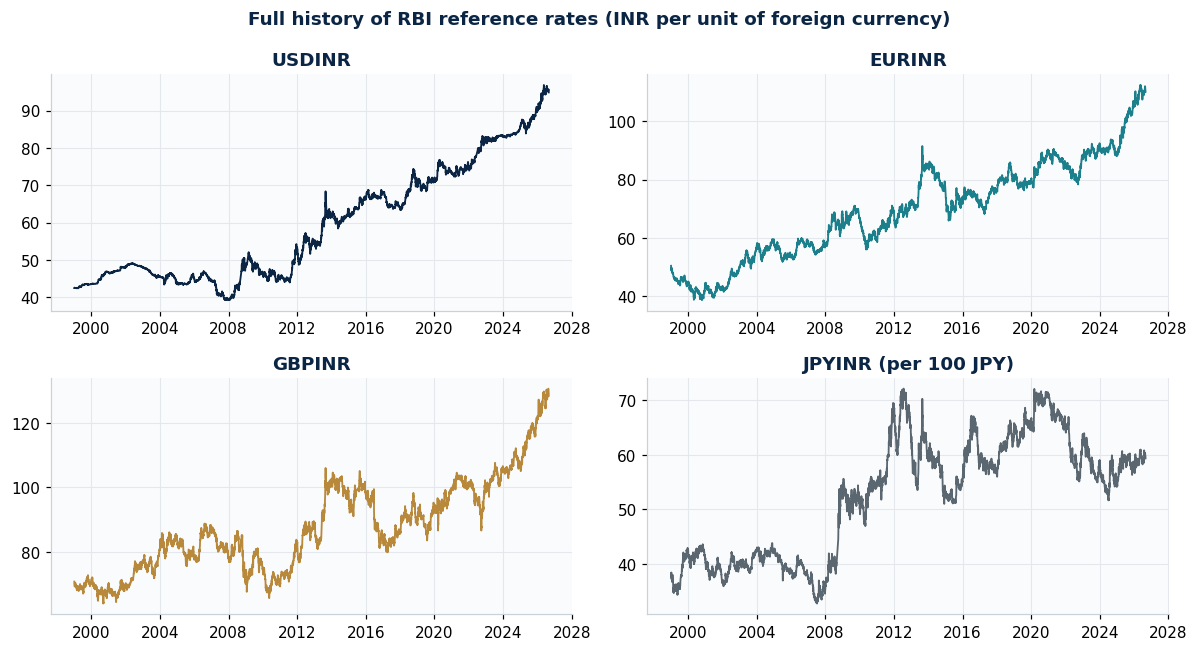

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, c in zip(axes.ravel(), fx.columns):
    ax.plot(fx[c], color=COLORS[c], lw=1.2)
    ax.set_title(c + (" (per 100 JPY)" if c == "JPYINR" else ""))
fig.suptitle("Full history of RBI reference rates (INR per unit of foreign currency)", color=NAVY, fontweight="bold")
save("01_full_history")

Change over window (%):
 USDINR    30.0
EURINR    27.9
GBPINR    28.0
JPYINR   -10.4


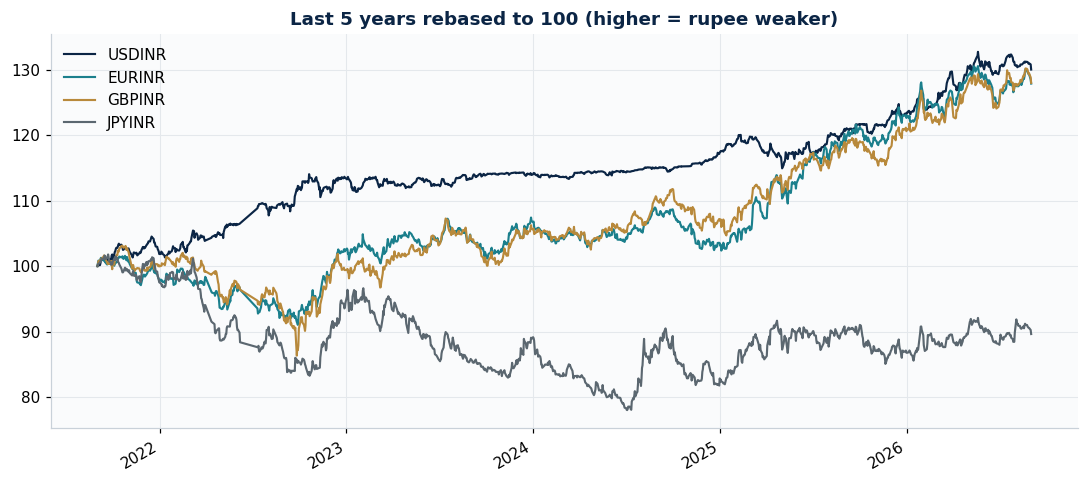

In [4]:
rebased = px / px.iloc[0] * 100
ax = rebased.plot(figsize=(10, 4.5), color=[COLORS[c] for c in rebased.columns], lw=1.4)
ax.set_title("Last 5 years rebased to 100 (higher = rupee weaker)"); ax.set_xlabel(""); ax.legend(frameon=False)
save("02_rebased")
print("Change over window (%):\n", ((px.iloc[-1] / px.iloc[0] - 1) * 100).round(1).to_string())

## 2. Time-series analysis (returns, distribution, trend, autocorrelation)

In [5]:
ret = np.log(px).diff().dropna()     # daily log returns
summary = pd.DataFrame({
    "mean_daily_%": ret.mean() * 100, "std_daily_%": ret.std() * 100,
    "skewness": ret.skew(), "excess_kurtosis": ret.kurt(),
    "jarque_bera_p": [stats.jarque_bera(ret[c])[1] for c in ret]})
print(summary.round(4).to_string())

acf = pd.DataFrame({"lag1_price_level": [px[c].autocorr(1) for c in px],
                    "lag1_return": [ret[c].autocorr(1) for c in ret],
                    "lag1_squared_return": [(ret[c] ** 2).autocorr(1) for c in ret]}, index=ret.columns)
print("\nAutocorrelation:\n", acf.round(3).to_string())

# Long-run trend: regress log(price) on time (years) over the full history
yrs = (fx.index - fx.index[0]).days / 365.25
trend = {c: (np.exp(stats.linregress(yrs, np.log(fx[c])).slope) - 1) * 100 for c in fx}
print("\nLong-run trend (% change per year in INR cost of the currency):\n", pd.Series(trend).round(2).to_string())

print("\nInterpretation:")
print(f"- Price levels have lag-1 autocorrelation ~{acf['lag1_price_level'].mean():.2f} (non-stationary, trending); returns are close to 0 "
      f"(avg {acf['lag1_return'].mean():.2f}), so we model returns, not levels.")
print(f"- Excess kurtosis averages {summary['excess_kurtosis'].mean():.1f} and Jarque-Bera p-values are "
      f"{'all below 0.05' if (summary['jarque_bera_p'] < 0.05).all() else 'mixed'}: returns have fat tails, not exactly normal.")
print(f"- Squared-return autocorrelation avg {acf['lag1_squared_return'].mean():.2f}: volatility clusters (calm and turbulent periods).")

        mean_daily_%  std_daily_%  skewness  excess_kurtosis  jarque_bera_p
USDINR        0.0223       0.2729    0.0746           6.8321            0.0
EURINR        0.0208       0.4577   -0.2783           3.2325            0.0
GBPINR        0.0209       0.5130   -0.5430           8.6935            0.0
JPYINR       -0.0093       0.6566    0.5879           4.3497            0.0

Autocorrelation:
         lag1_price_level  lag1_return  lag1_squared_return
USDINR             0.999       -0.012                0.087
EURINR             0.999        0.049                0.095
GBPINR             0.998        0.029                0.086
JPYINR             0.993        0.021                0.141

Long-run trend (% change per year in INR cost of the currency):
 USDINR    2.97
EURINR    3.07
GBPINR    1.72
JPYINR    2.20

Interpretation:
- Price levels have lag-1 autocorrelation ~1.00 (non-stationary, trending); returns are close to 0 (avg 0.02), so we model returns, not levels.
- Excess kurtosis a

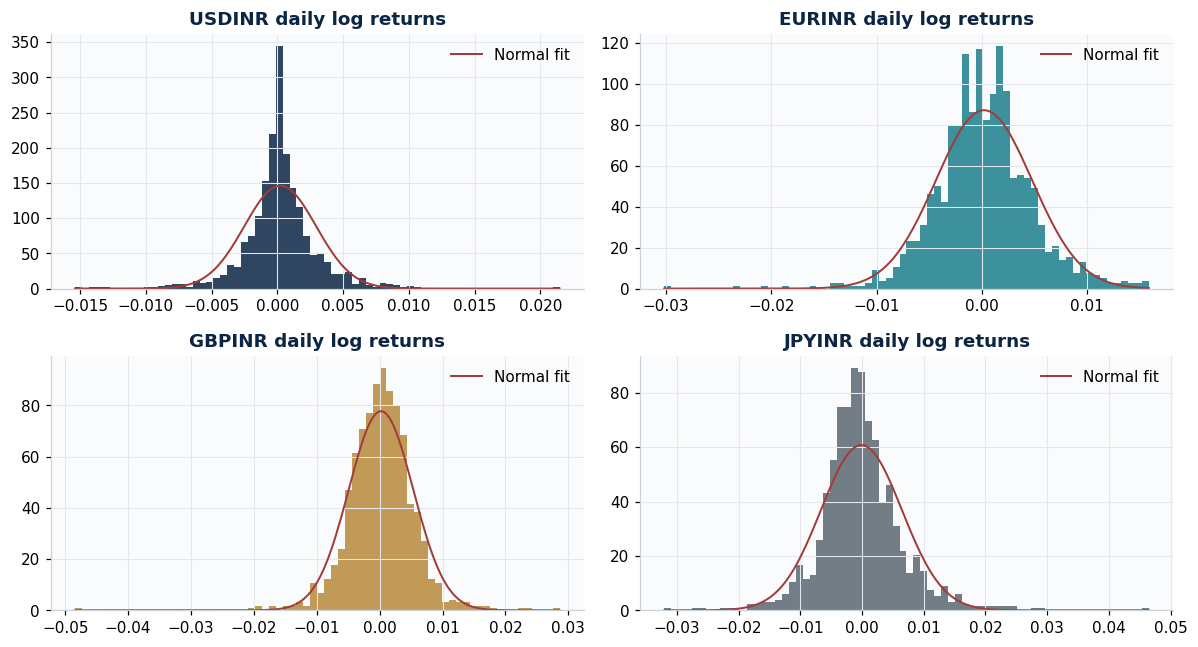

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, c in zip(axes.ravel(), ret.columns):
    ax.hist(ret[c], bins=70, density=True, color=COLORS[c], alpha=0.85)
    xs = np.linspace(ret[c].min(), ret[c].max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, ret[c].mean(), ret[c].std()), color=RED, lw=1.3, label="Normal fit")
    ax.set_title(f"{c} daily log returns"); ax.legend(frameon=False)
save("03_return_distributions")

## 3. Moving averages (trend signals)

In [7]:
sma = {}
for c in px:
    sma[c] = pd.DataFrame({"price": px[c], "SMA20": px[c].rolling(20).mean(),
                           "SMA50": px[c].rolling(50).mean(), "SMA200": px[c].rolling(200).mean()})

rows = []
for c, s in sma.items():
    d = (s["SMA50"] - s["SMA200"]).dropna()
    sign = np.sign(d)
    changes = sign[sign != sign.shift()].index[1:]      # first valid date is not a crossover
    last_cross = changes[-1].date() if len(changes) else "none in window"
    rows.append({"pair": c, "price": s["price"].iloc[-1], "SMA50": s["SMA50"].iloc[-1], "SMA200": s["SMA200"].iloc[-1],
                 "price_vs_SMA50": "above" if s["price"].iloc[-1] > s["SMA50"].iloc[-1] else "below",
                 "trend (SMA50 vs SMA200)": "Uptrend (INR weakening)" if d.iloc[-1] > 0 else "Downtrend (INR strengthening)",
                 "last_cross_date": last_cross})
ma_table = pd.DataFrame(rows).set_index("pair")
print(ma_table.round(3).to_string())

          price    SMA50   SMA200 price_vs_SMA50  trend (SMA50 vs SMA200) last_cross_date
pair                                                                                     
USDINR   94.870   95.511   92.934          below  Uptrend (INR weakening)  none in window
EURINR  110.069  109.734  108.049          above  Uptrend (INR weakening)      2025-03-19
GBPINR  128.431  128.215  124.706          above  Uptrend (INR weakening)      2025-03-10
JPYINR   59.310   59.375   58.745          below  Uptrend (INR weakening)      2026-04-08


Interpretation: when SMA50 is above SMA200 the medium-term trend is up (the currency is getting costlier in INR). A crossover signals a possible change in trend; moving averages lag price, so they confirm trends rather than predict them.


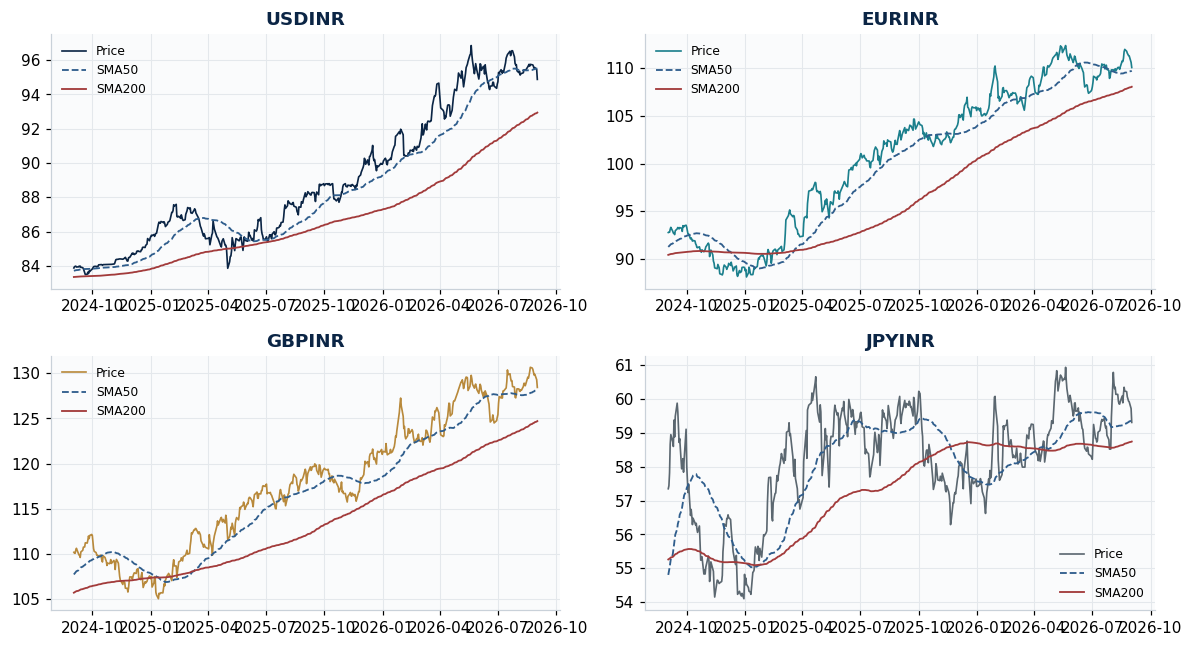

In [8]:
last2 = px.index[-1] - pd.DateOffset(years=2)
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (c, s) in zip(axes.ravel(), sma.items()):
    s = s.loc[last2:]
    ax.plot(s["price"], color=COLORS[c], lw=1.1, label="Price")
    ax.plot(s["SMA50"], color=BLUE, lw=1.2, ls="--", label="SMA50")
    ax.plot(s["SMA200"], color=RED, lw=1.2, label="SMA200")
    ax.set_title(c); ax.legend(frameon=False, fontsize=8)
save("04_moving_averages")
print("Interpretation: when SMA50 is above SMA200 the medium-term trend is up (the currency is getting costlier in INR). "
      "A crossover signals a possible change in trend; moving averages lag price, so they confirm trends rather than predict them.")

## 4. Risk metrics (volatility, VaR, CVaR, drawdown, correlation)

In [9]:
POSITION = 1_000_000  # illustrative INR exposure per currency
rows = {}
for c in ret:
    r = ret[c]
    q5, q1 = np.percentile(r, 5), np.percentile(r, 1)
    rows[c] = {
        "ann_return_%": r.mean() * TRADING_DAYS * 100,
        "ann_volatility_%": r.std() * np.sqrt(TRADING_DAYS) * 100,
        "sharpe": (r.mean() * TRADING_DAYS - RISK_FREE) / (r.std() * np.sqrt(TRADING_DAYS)),
        "VaR95_hist_%": -q5 * 100, "VaR99_hist_%": -q1 * 100,
        "VaR95_normal_%": -(r.mean() + stats.norm.ppf(0.05) * r.std()) * 100,
        "CVaR95_%": -r[r <= q5].mean() * 100,
        "max_drawdown_%": ((px[c] / px[c].cummax() - 1).min()) * 100,
        "VaR95_INR_on_10L": -q5 * POSITION}
risk = pd.DataFrame(rows).T
print(risk.round(3).to_string())

top = risk["ann_volatility_%"].idxmax(); low = risk["ann_volatility_%"].idxmin()
print("\nInterpretation:")
print(f"- {top} is the most volatile pair ({risk.loc[top, 'ann_volatility_%']:.1f}% a year); {low} is the least ({risk.loc[low, 'ann_volatility_%']:.1f}%).")
print(f"- 1-day 95% VaR for {top} is {risk.loc[top, 'VaR95_hist_%']:.2f}%: on 95% of days the loss should not exceed this "
      f"(about Rs {risk.loc[top, 'VaR95_INR_on_10L']:,.0f} on a Rs 10 lakh position).")
print("- CVaR is larger than VaR because it averages the losses beyond the VaR cut-off (tail risk).")
print("- Max drawdown is measured as a fall in the INR value of the currency (i.e. the rupee strengthening).")

        ann_return_%  ann_volatility_%  sharpe  VaR95_hist_%  VaR99_hist_%  VaR95_normal_%  CVaR95_%  max_drawdown_%  VaR95_INR_on_10L
USDINR         5.608             4.333  -0.090         0.381         0.776           0.427     0.635          -4.258          3808.807
EURINR         5.253             7.266  -0.103         0.678         1.081           0.732     0.994         -10.379          6779.239
GBPINR         5.270             8.143  -0.090         0.739         1.270           0.823     1.131         -16.282          7389.145
JPYINR        -2.341            10.422  -0.800         0.993         1.620           1.089     1.399         -23.367          9925.989

Interpretation:
- JPYINR is the most volatile pair (10.4% a year); USDINR is the least (4.3%).
- 1-day 95% VaR for JPYINR is 0.99%: on 95% of days the loss should not exceed this (about Rs 9,926 on a Rs 10 lakh position).
- CVaR is larger than VaR because it averages the losses beyond the VaR cut-off (tail risk).
- Max dra

        USDINR  EURINR  GBPINR  JPYINR
USDINR    1.00    0.12    0.08    0.20
EURINR    0.12    1.00    0.75    0.52
GBPINR    0.08    0.75    1.00    0.43
JPYINR    0.20    0.52    0.43    1.00


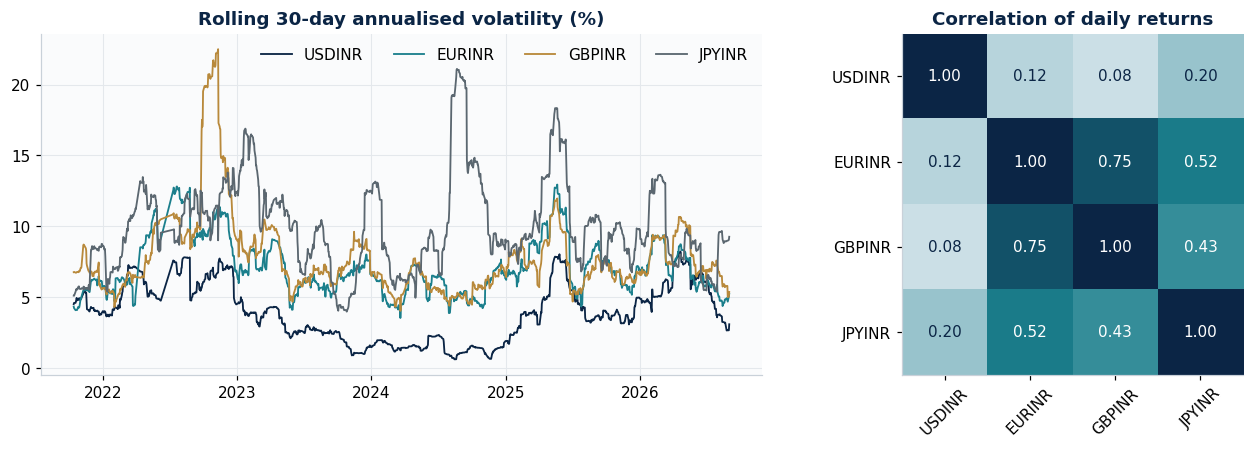

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
rv = ret.rolling(30).std() * np.sqrt(TRADING_DAYS) * 100
for c in rv: axes[0].plot(rv[c], color=COLORS[c], lw=1.2, label=c)
axes[0].set_title("Rolling 30-day annualised volatility (%)"); axes[0].legend(frameon=False, ncol=4)
corr = ret.corr()
cmap = LinearSegmentedColormap.from_list("pro", ["#EAF0F6", TEAL, NAVY])
axes[1].imshow(corr, cmap=cmap, vmin=0, vmax=1); axes[1].grid(False)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(corr.columns, rotation=45); axes[1].set_yticks(range(4)); axes[1].set_yticklabels(corr.columns)
for i in range(4):
    for j in range(4): axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="white" if corr.iloc[i, j] > 0.4 else NAVY)
axes[1].set_title("Correlation of daily returns")
save("05_volatility_correlation")
print(corr.round(2).to_string())

## 5. Markowitz mean-variance portfolio

In [11]:
mu, cov = ret.mean() * TRADING_DAYS, ret.cov() * TRADING_DAYS
n = len(mu)
rng = np.random.default_rng(SEED)
W = rng.dirichlet(np.ones(n), 5000)                       # 5000 random long-only portfolios
p_ret = W @ mu.values
p_vol = np.sqrt(np.einsum("ij,jk,ik->i", W, cov.values, W))
p_sr = (p_ret - RISK_FREE) / p_vol

variance = lambda w: w @ cov.values @ w
neg_sharpe = lambda w: -((w @ mu.values - RISK_FREE) / np.sqrt(w @ cov.values @ w))
cons, bnds, w0 = {"type": "eq", "fun": lambda w: w.sum() - 1}, [(0, 1)] * n, np.ones(n) / n
w_min = optimize.minimize(variance, w0, bounds=bnds, constraints=cons).x
w_max = optimize.minimize(neg_sharpe, w0, bounds=bnds, constraints=cons).x

def describe(w):
    pr = ret.values @ w
    return {"exp_return_%": w @ mu.values * 100, "volatility_%": np.sqrt(variance(w)) * 100,
            "sharpe": -neg_sharpe(w), "VaR95_1d_%": -np.percentile(pr, 5) * 100}
portfolios = {"Equal weight": w0, "Minimum variance": w_min, "Maximum Sharpe": w_max}
weights = pd.DataFrame(portfolios, index=ret.columns).T * 100
perf = pd.DataFrame({k: describe(w) for k, w in portfolios.items()}).T
print("Weights (%):\n", weights.round(1).to_string())
print("\nPerformance:\n", perf.round(3).to_string())
print("\nInterpretation:")
print(f"- Minimum-variance portfolio puts most weight on {weights.loc['Minimum variance'].idxmax()} "
      f"({weights.loc['Minimum variance'].max():.0f}%); volatility {perf.loc['Minimum variance', 'volatility_%']:.2f}% vs equal-weight {perf.loc['Equal weight', 'volatility_%']:.2f}%.")
print(f"- Maximum-Sharpe portfolio favours {weights.loc['Maximum Sharpe'].idxmax()} ({weights.loc['Maximum Sharpe'].max():.0f}%). "
      "Caution: this uses past average returns, which are noisy, so treat the weights as illustrative.")

Weights (%):
                   USDINR  EURINR  GBPINR  JPYINR
Equal weight        25.0    25.0    25.0    25.0
Minimum variance    75.5    15.3     9.2     0.0
Maximum Sharpe       0.0     0.0   100.0     0.0

Performance:
                   exp_return_%  volatility_%  sharpe  VaR95_1d_%
Equal weight             3.448         5.694  -0.448       0.505
Minimum variance         5.523         3.874  -0.123       0.346
Maximum Sharpe           5.270         8.143  -0.090       0.739

Interpretation:
- Minimum-variance portfolio puts most weight on USDINR (75%); volatility 3.87% vs equal-weight 5.69%.
- Maximum-Sharpe portfolio favours GBPINR (100%). Caution: this uses past average returns, which are noisy, so treat the weights as illustrative.


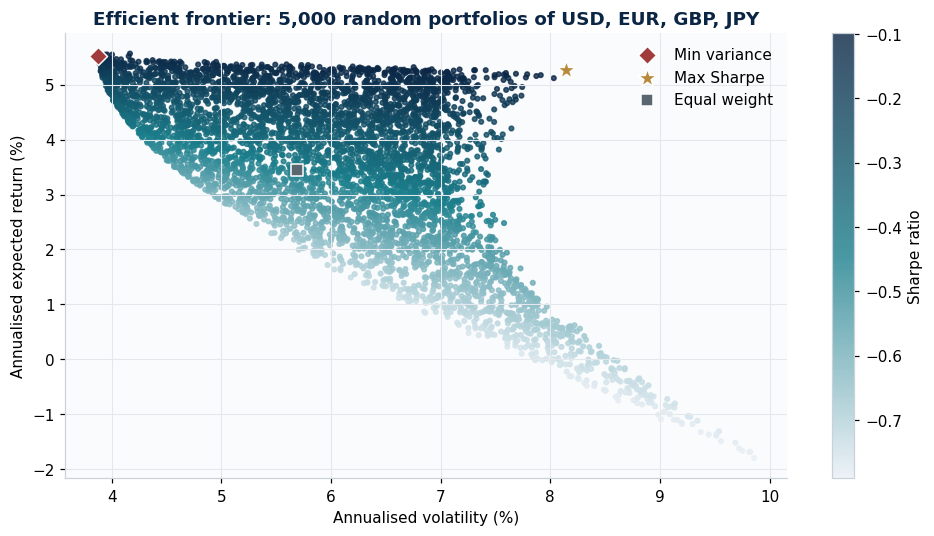

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(p_vol * 100, p_ret * 100, c=p_sr, cmap=cmap, s=9, alpha=0.8)
plt.colorbar(sc, label="Sharpe ratio")
for name, w, mk, col in [("Min variance", w_min, "D", RED), ("Max Sharpe", w_max, "*", GOLD), ("Equal weight", w0, "s", SLATE)]:
    d = describe(w); ax.scatter(d["volatility_%"], d["exp_return_%"], marker=mk, s=170 if mk == "*" else 70, color=col, edgecolor="white", zorder=5, label=name)
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("Annualised expected return (%)")
ax.set_title("Efficient frontier: 5,000 random portfolios of USD, EUR, GBP, JPY"); ax.legend(frameon=False)
save("06_efficient_frontier")

## 6. Financial text analytics (lexicon-based sentiment)
`data/sample_headlines.csv` holds **illustrative** headlines. Replace them with real news (e.g. from a news site or API) for a real study.

In [13]:
heads = pd.read_csv(DATA / "sample_headlines.csv", parse_dates=["date"])
POS = {"gains", "strengthens", "supports", "inflows", "rallies", "steady", "improved", "cools", "easing", "lifts", "holds"}
NEG = {"weakens", "falls", "slides", "outflows", "deficit", "pressure", "pressures", "selloff", "volatile", "low", "slump", "fall"}

def score(text):
    words = [w.strip(".,").lower() for w in text.split()]
    return sum(w in POS for w in words) - sum(w in NEG for w in words)

heads["rupee_sentiment"] = heads["headline"].apply(score)
by_pair = heads.groupby("currency")["rupee_sentiment"].agg(["mean", "count"])
print(heads[["currency", "rupee_sentiment", "headline"]].to_string(index=False))
print("\nAverage rupee sentiment by pair:\n", by_pair.round(2).to_string())
words = pd.Series([w.strip(".,").lower() for h in heads["headline"] for w in h.split()])
print("\nMost frequent finance words:", words[words.isin(POS | NEG)].value_counts().head(6).to_dict())
print("\nInterpretation: a positive score means the headline wording is favourable to the rupee, a negative score is unfavourable. "
      "A simple word list ignores context (e.g. 'Yen slides and rupee rallies'), so results are indicative only.")

currency  rupee_sentiment                                                             headline
  USDINR               -2 Rupee weakens as importers buy dollars and foreign outflows continue
  USDINR                3        Rupee gains on strong foreign inflows and easing crude prices
  USDINR               -3                    Rupee slides to fresh low as trade deficit widens
  USDINR                0                     RBI intervention supports rupee after sharp fall
  EURINR               -1              Euro rally pressures rupee as eurozone growth surprises
  EURINR                2            Rupee strengthens against euro after improved export data
  EURINR               -1                       Rupee falls versus euro on hawkish ECB signals
  EURINR                2                    Rupee holds steady against euro amid calm markets
  GBPINR               -1             Sterling climbs and rupee weakens on strong UK jobs data
  GBPINR                2                       Ru

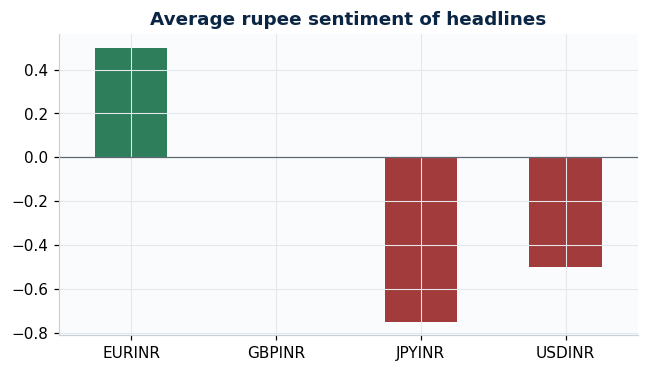

In [14]:
ax = by_pair["mean"].plot.bar(color=[GREEN if v > 0 else RED for v in by_pair["mean"]], figsize=(6, 3.5), rot=0)
ax.axhline(0, color=SLATE, lw=0.8); ax.set_title("Average rupee sentiment of headlines"); ax.set_xlabel("")
save("07_text_sentiment")

## 7. Save results

In [15]:
for name, df in {"summary_stats": summary, "risk_metrics": risk, "moving_average_signals": ma_table,
                 "portfolio_weights": weights, "portfolio_performance": perf, "headline_sentiment": heads}.items():
    df.to_csv(OUT / f"{name}.csv", float_format="%.4f")
print("Saved tables to outputs/ and figures to outputs/figures/")

Saved tables to outputs/ and figures to outputs/figures/
